In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler




In [4]:
# Load dataset
data = pd.read_csv("diabetes_prediction_dataset.csv")

# Separate features and target
X = data.drop("diabetes", axis=1)
y = data["diabetes"]

# Convert categorical variables
X = pd.get_dummies(X)

# Normalize data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert to tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.long)


In [5]:
def split_data(X, y, num_clients=3):
    size = len(X) // num_clients
    clients = []

    for i in range(num_clients):
        start = i * size
        end = (i + 1) * size
        clients.append((X[start:end], y[start:end]))

    return clients

clients_data = split_data(X, y, 3)


In [6]:
def train_local(model, X, y, epochs=3):
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()

    for epoch in range(epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            output = model(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    return model.state_dict()


In [7]:
def federated_average(models):
    avg_model = {}

    for key in models[0].keys():
        avg_model[key] = torch.mean(
            torch.stack([model[key].float() for model in models]), dim=0
        )

    return avg_model


In [8]:
input_dim = X.shape[1]
global_model = DiabetesModel(input_dim)

rounds = 5

for round in range(rounds):
    print(f"\n--- Federated Round {round+1} ---")

    local_weights = []

    for i, (X_client, y_client) in enumerate(clients_data):
        local_model = DiabetesModel(input_dim)
        local_model.load_state_dict(global_model.state_dict())

        weights = train_local(local_model, X_client, y_client)
        local_weights.append(weights)

        print(f"Client {i+1} trained.")

    # Federated Averaging
    averaged_weights = federated_average(local_weights)
    global_model.load_state_dict(averaged_weights)

    print("Global model updated.")



--- Federated Round 1 ---
Client 1 trained.
Client 2 trained.
Client 3 trained.
Global model updated.

--- Federated Round 2 ---
Client 1 trained.
Client 2 trained.
Client 3 trained.
Global model updated.

--- Federated Round 3 ---
Client 1 trained.
Client 2 trained.
Client 3 trained.
Global model updated.

--- Federated Round 4 ---
Client 1 trained.
Client 2 trained.
Client 3 trained.
Global model updated.

--- Federated Round 5 ---
Client 1 trained.
Client 2 trained.
Client 3 trained.
Global model updated.


In [9]:
def evaluate(model, X, y):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    accuracy = correct / total
    print(f"\nFinal Global Model Accuracy: {accuracy*100:.2f}%")

evaluate(global_model, X, y)



Final Global Model Accuracy: 97.19%


In [11]:
# Set model to evaluation mode
global_model.eval()

with torch.no_grad():
    outputs = global_model(X)
    
    # Convert logits to probabilities
    probabilities = torch.softmax(outputs, dim=1)[:, 1]  # Probability of class 1 (diabetes)


In [12]:
# Convert tensors to numpy
y_true = y.numpy()
y_scores = probabilities.numpy()

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Calculate AUC score
auc_score = roc_auc_score(y_true, y_scores)

print("ROC-AUC Score:", auc_score)


ROC-AUC Score: 0.9781005728061717


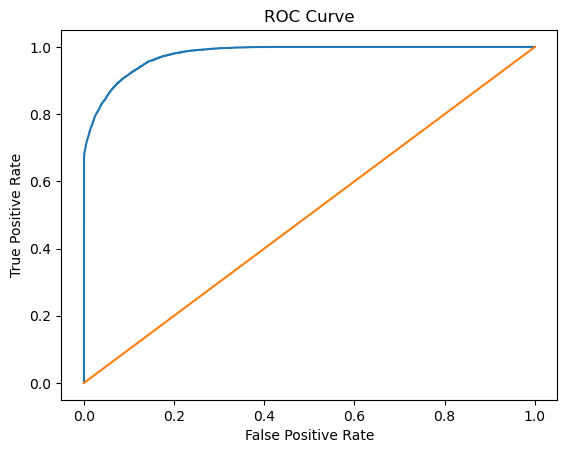

In [13]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # Diagonal line (Random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [14]:
# Load dataset
data = pd.read_csv("diabetes_prediction_dataset.csv")

# Separate features and target
X = data.drop("diabetes", axis=1)
y = data["diabetes"]

# Convert categorical variables
X = pd.get_dummies(X)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Get feature importance
importances = rf.feature_importances_
feature_names = X.columns


In [18]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

print(feature_importance_df)


                        Feature  Importance
4                   HbA1c_level    0.405069
5           blood_glucose_level    0.317308
3                           bmi    0.127016
0                           age    0.103133
1                  hypertension    0.015728
2                 heart_disease    0.010482
9       smoking_history_No Info    0.004267
12       smoking_history_former    0.003590
13        smoking_history_never    0.003035
10      smoking_history_current    0.002350
7                   gender_Male    0.002216
6                 gender_Female    0.002034
11         smoking_history_ever    0.001895
14  smoking_history_not current    0.001873
8                  gender_Other    0.000002


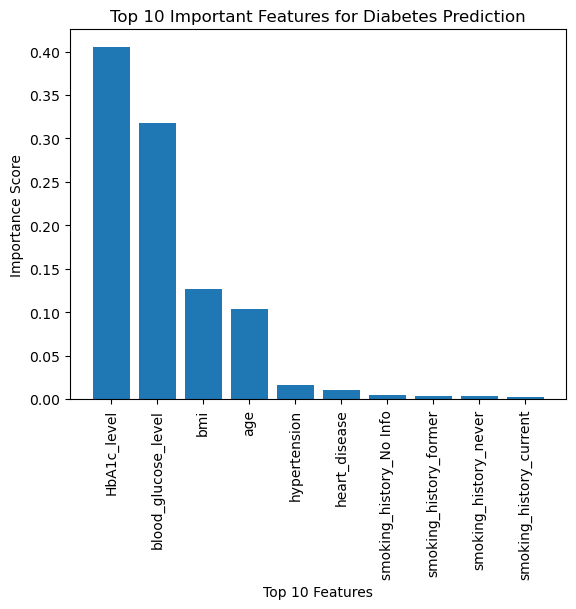

In [19]:
plt.figure()
plt.bar(feature_importance_df["Feature"][:10],
        feature_importance_df["Importance"][:10])

plt.xticks(rotation=90)
plt.xlabel("Top 10 Features")
plt.ylabel("Importance Score")
plt.title("Top 10 Important Features for Diabetes Prediction")
plt.show()


In [20]:
top_features = feature_importance_df["Feature"][:5]
X_selected = X[top_features]

print("Selected Features:")
print(top_features)


Selected Features:
4            HbA1c_level
5    blood_glucose_level
3                    bmi
0                    age
1           hypertension
Name: Feature, dtype: object
